**Objective:**

We are dealing with multiple `stationID` values occurring at the same `connectionTime` and outliers in the `KWhDelivered`, `total_charging_time`, and `idle_time` variables in this notebook. Also used Isolation Forest for Anomaly Detection.

**Input**: `df_JPL_data_clean_NoUser.csv`

**Output**: `acn_jpl_0.2_0.1_with_stationID_22_06_2023.csv`

**Reference**:`16/03/2023 JPL TCN stationID part-1.ipynb`

# Mounting and Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/My Drive/TL_A/DeepKale/experiments_0.2/notebook/data_processing/base_model/")
!ls

19062023_caltech_data_preprocessing_with_stationID_part_1.ipynb
19062023_caltech_jpl_data_preprocessing_without_stationID_part_2.ipynb
19062023_jpl_data_preprocessing_with_stationID_part_1.ipynb


In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline, interp1d
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import IsolationForest

SEED = 42
np.random.seed(SEED)

# Reading the CSV

In [ ]:
df_jpl = pd.read_csv('../../../data/preprocessed/ACN/df_JPL_data_clean_NoUser.csv')

In [ ]:
df_jpl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28391 entries, 0 to 28390
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               28391 non-null  object 
 1   clusterID         28391 non-null  int64  
 2   connectionTime    28391 non-null  object 
 3   disconnectTime    28391 non-null  object 
 4   doneChargingTime  28391 non-null  object 
 5   kWhDelivered      28391 non-null  float64
 6   sessionID         28391 non-null  object 
 7   siteID            28391 non-null  int64  
 8   spaceID           28391 non-null  object 
 9   stationID         28391 non-null  object 
 10  futility_time     28391 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.4+ MB


In [ ]:
df_jpl.shape

(28391, 11)

In [ ]:
df_jpl.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,futility_time
0,5c36631ef9af8b4639a8e581,1,2018-10-08 13:01:34+00:00,2018-10-09 00:09:54+00:00,2018-10-09 00:00:02+00:00,12.065,1_1_179_797_2018-10-08 13:01:33.541148,1,AG-3F23,1-1-179-797,0 days 00:09:52
1,5c36631ef9af8b4639a8e588,1,2018-10-08 13:24:48+00:00,2018-10-09 00:05:33+00:00,2018-10-09 00:00:02+00:00,6.314,1_1_193_816_2018-10-08 13:24:47.751438,1,AG-1F05,1-1-193-816,0 days 00:05:31
2,5c36631ef9af8b4639a8e58b,1,2018-10-08 13:34:52+00:00,2018-10-09 00:43:48+00:00,2018-10-09 00:00:03+00:00,22.845,1_1_179_810_2018-10-08 13:34:52.479296,1,AG-3F30,1-1-179-810,0 days 00:43:45
3,5c36631ef9af8b4639a8e593,1,2018-10-08 13:59:16+00:00,2018-10-09 00:28:04+00:00,2018-10-09 00:00:01+00:00,25.382,1_1_179_777_2018-10-08 13:59:15.937669,1,AG-3F28,1-1-179-777,0 days 00:28:03
4,5c36631ef9af8b4639a8e595,1,2018-10-08 14:01:14+00:00,2018-10-09 00:18:52+00:00,2018-10-09 00:00:03+00:00,11.694,1_1_179_781_2018-10-08 14:01:13.740753,1,AG-3F31,1-1-179-781,0 days 00:18:49


# Detailed Analysis and exploration with `StationID`

**Checking whether the stationID and spaceID infers the same information or not!**

In [ ]:
# group the dataframe by spaceID and stationID columns and count the number of unique values for stationID in each group
stationID_counts = df_jpl.groupby(['spaceID', 'stationID'])['stationID'].nunique()

# check if there are any groups where stationID has more than one unique value
if (stationID_counts > 1).any():
    print("There are groups where stationID has different values for the same spaceID.")
else:
    print("stationID has the same value for all rows with the same spaceID.")

stationID has the same value for all rows with the same spaceID.


**Some sanity check**

In [ ]:
# select all rows with spaceID equal to AG-3F23
df_AG_3F23 = df_jpl.loc[df_jpl['spaceID'] == 'AG-3F23']

# display the selected rows
df_AG_3F23

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,futility_time
0,5c36631ef9af8b4639a8e581,1,2018-10-08 13:01:34+00:00,2018-10-09 00:09:54+00:00,2018-10-09 00:00:02+00:00,12.065,1_1_179_797_2018-10-08 13:01:33.541148,1,AG-3F23,1-1-179-797,0 days 00:09:52
50,5c366352f9af8b4639a8e5d3,1,2018-10-09 13:38:12+00:00,2018-10-10 00:44:11+00:00,2018-10-09 17:28:00+00:00,10.655,1_1_179_797_2018-10-09 13:38:12.005403,1,AG-3F23,1-1-179-797,0 days 07:16:11
129,5c36639ff9af8b4639a8e625,1,2018-10-10 14:30:36+00:00,2018-10-10 23:24:58+00:00,2018-10-10 20:11:32+00:00,23.950,1_1_179_797_2018-10-10 14:30:36.289066,1,AG-3F23,1-1-179-797,0 days 03:13:26
192,5c3663eaf9af8b4639a8e666,1,2018-10-11 14:22:47+00:00,2018-10-11 20:03:04+00:00,2018-10-11 17:42:22+00:00,10.591,1_1_179_797_2018-10-11 14:22:46.991578,1,AG-3F23,1-1-179-797,0 days 02:20:42
300,5c36645ef9af8b4639a8e6d7,1,2018-10-15 14:31:43+00:00,2018-10-16 00:14:52+00:00,2018-10-15 23:45:25+00:00,20.348,1_1_179_797_2018-10-15 14:31:43.268725,1,AG-3F23,1-1-179-797,0 days 00:29:27
...,...,...,...,...,...,...,...,...,...,...,...
28140,6147da15f9af8b62796fa116,1,2021-09-03 16:41:50+00:00,2021-09-03 22:47:40+00:00,2021-09-03 22:47:31+00:00,35.538,1_1_179_797_2021-09-03 16:41:41.354209,1,AG-3F23,1-1-179-797,0 days 00:00:09
28191,614d1c47f9af8b6a7d813e0a,1,2021-09-07 15:58:37+00:00,2021-09-08 03:00:11+00:00,2021-09-08 03:00:06+00:00,0.974,1_1_179_797_2021-09-07 15:58:27.268076,1,AG-3F23,1-1-179-797,0 days 00:00:05
28225,614e6dc3f9af8b6c6e8d5b01,1,2021-09-08 13:46:04+00:00,2021-09-08 22:40:57+00:00,2021-09-08 21:11:53+00:00,40.154,1_1_179_797_2021-09-08 13:46:03.740850,1,AG-3F23,1-1-179-797,0 days 01:29:04
28293,614fbf42f9af8b6e5166424a,1,2021-09-09 16:31:04+00:00,2021-09-10 03:10:22+00:00,2021-09-09 17:52:32+00:00,7.503,1_1_179_797_2021-09-09 16:30:50.985923,1,AG-3F23,1-1-179-797,0 days 09:17:50


**Some sanity check**

In [ ]:
# select all rows with spaceID equal to AG-1F05
df_AG_1F05 = df_jpl.loc[df_jpl['spaceID'] == 'AG-1F05']

# display the selected rows
df_AG_1F05

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,futility_time
1,5c36631ef9af8b4639a8e588,1,2018-10-08 13:24:48+00:00,2018-10-09 00:05:33+00:00,2018-10-09 00:00:02+00:00,6.314,1_1_193_816_2018-10-08 13:24:47.751438,1,AG-1F05,1-1-193-816,0 days 00:05:31
46,5c366352f9af8b4639a8e5cf,1,2018-10-09 13:21:47+00:00,2018-10-10 00:38:55+00:00,2018-10-09 14:49:03+00:00,3.374,1_1_193_816_2018-10-09 13:21:47.265308,1,AG-1F05,1-1-193-816,0 days 09:49:52
122,5c36639ff9af8b4639a8e61e,1,2018-10-10 14:09:16+00:00,2018-10-10 23:35:21+00:00,2018-10-10 23:35:16+00:00,50.901,1_1_193_816_2018-10-10 14:09:15.623739,1,AG-1F05,1-1-193-816,0 days 00:00:05
180,5c3663eaf9af8b4639a8e65a,1,2018-10-11 13:23:56+00:00,2018-10-11 23:07:22+00:00,2018-10-11 17:03:21+00:00,8.457,1_1_193_816_2018-10-11 13:23:56.359436,1,AG-1F05,1-1-193-816,0 days 06:04:01
235,5c3663eaf9af8b4639a8e693,1,2018-10-11 23:41:23+00:00,2018-10-12 01:00:05+00:00,2018-10-12 00:59:59+00:00,7.303,1_1_193_816_2018-10-11 23:41:22.968799,1,AG-1F05,1-1-193-816,0 days 00:00:06
...,...,...,...,...,...,...,...,...,...,...,...
28172,614d1c47f9af8b6a7d813df7,1,2021-09-07 14:04:11+00:00,2021-09-07 23:15:25+00:00,2021-09-07 23:15:20+00:00,44.065,1_1_193_816_2021-09-07 14:04:10.709605,1,AG-1F05,1-1-193-816,0 days 00:00:05
28227,614e6dc3f9af8b6c6e8d5b03,1,2021-09-08 13:49:38+00:00,2021-09-09 01:04:03+00:00,2021-09-08 17:47:32+00:00,10.010,1_1_193_816_2021-09-08 13:49:28.363507,1,AG-1F05,1-1-193-816,0 days 07:16:31
28274,614fbf42f9af8b6e51664237,1,2021-09-09 14:30:20+00:00,2021-09-09 16:30:58+00:00,2021-09-09 16:30:55+00:00,9.879,1_1_193_816_2021-09-09 14:30:10.429346,1,AG-1F05,1-1-193-816,0 days 00:00:03
28300,614fbf42f9af8b6e51664261,1,2021-09-09 17:13:39+00:00,2021-09-09 23:59:15+00:00,2021-09-09 20:12:02+00:00,11.119,1_1_193_816_2021-09-09 17:13:38.504221,1,AG-1F05,1-1-193-816,0 days 03:47:13


**So we can drop the `spaceID`**

In [ ]:
# drop the 'spaceID' column from the df_jpl dataframe
df_jpl = df_jpl.drop('spaceID', axis=1)

In [ ]:
df_jpl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28391 entries, 0 to 28390
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               28391 non-null  object 
 1   clusterID         28391 non-null  int64  
 2   connectionTime    28391 non-null  object 
 3   disconnectTime    28391 non-null  object 
 4   doneChargingTime  28391 non-null  object 
 5   kWhDelivered      28391 non-null  float64
 6   sessionID         28391 non-null  object 
 7   siteID            28391 non-null  int64  
 8   stationID         28391 non-null  object 
 9   futility_time     28391 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 2.2+ MB


**Checking for Unique `StationID`**

In [ ]:
# get all the unique values of the 'stationID' column in the df_jpl dataframe
unique_station_ids = df_jpl['stationID'].unique()

# display the unique values
unique_station_ids

array(['1-1-179-797', '1-1-193-816', '1-1-179-810', '1-1-179-777',
       '1-1-179-781', '1-1-179-791', '1-1-179-799', '1-1-179-796',
       '1-1-179-794', '1-1-191-803', '1-1-191-807', '1-1-191-795',
       '1-1-191-778', '1-1-191-784', '1-1-191-792', '1-1-191-804',
       '1-1-191-812', '1-1-191-808', '1-1-191-806', '1-1-191-785',
       '1-1-179-815', '1-1-194-821', '1-1-191-780', '1-1-193-820',
       '1-1-179-788', '1-1-178-817', '1-1-191-811', '1-1-191-786',
       '1-1-193-825', '1-1-194-822', '1-1-193-829', '1-1-194-826',
       '1-1-193-819', '1-1-178-824', '1-1-193-827', '1-1-191-789',
       '1-1-178-823', '1-1-191-802', '1-1-178-828', '1-1-194-818',
       '1-1-179-809', '1-1-179-783', '1-1-179-813', '1-1-179-798',
       '1-1-179-787', '1-1-179-801', '1-1-179-790', '1-1-179-779',
       '1-1-179-800', '1-1-191-805', '1-1-191-782', '1-1-191-793'],
      dtype=object)

In [ ]:
df_jpl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28391 entries, 0 to 28390
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               28391 non-null  object 
 1   clusterID         28391 non-null  int64  
 2   connectionTime    28391 non-null  object 
 3   disconnectTime    28391 non-null  object 
 4   doneChargingTime  28391 non-null  object 
 5   kWhDelivered      28391 non-null  float64
 6   sessionID         28391 non-null  object 
 7   siteID            28391 non-null  int64  
 8   stationID         28391 non-null  object 
 9   futility_time     28391 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 2.2+ MB


# Some experiments `stationID`

In [ ]:
mask = df_jpl['stationID'].str.strip().str.startswith('1-1', na=False) & (df_jpl['stationID'].str.count('-') == 1)
mask
print(df_jpl['stationID'].unique())

['1-1-179-797' '1-1-193-816' '1-1-179-810' '1-1-179-777' '1-1-179-781'
 '1-1-179-791' '1-1-179-799' '1-1-179-796' '1-1-179-794' '1-1-191-803'
 '1-1-191-807' '1-1-191-795' '1-1-191-778' '1-1-191-784' '1-1-191-792'
 '1-1-191-804' '1-1-191-812' '1-1-191-808' '1-1-191-806' '1-1-191-785'
 '1-1-179-815' '1-1-194-821' '1-1-191-780' '1-1-193-820' '1-1-179-788'
 '1-1-178-817' '1-1-191-811' '1-1-191-786' '1-1-193-825' '1-1-194-822'
 '1-1-193-829' '1-1-194-826' '1-1-193-819' '1-1-178-824' '1-1-193-827'
 '1-1-191-789' '1-1-178-823' '1-1-191-802' '1-1-178-828' '1-1-194-818'
 '1-1-179-809' '1-1-179-783' '1-1-179-813' '1-1-179-798' '1-1-179-787'
 '1-1-179-801' '1-1-179-790' '1-1-179-779' '1-1-179-800' '1-1-191-805'
 '1-1-191-782' '1-1-191-793']


In [ ]:
# create a boolean mask of rows where stationID starts with '1-1-'
mask = df_jpl['stationID'].str.startswith('1-1-')

# display the rows where stationID starts with '1-1-'
df_jpl[mask]

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5c36631ef9af8b4639a8e581,1,2018-10-08 13:01:34+00:00,2018-10-09 00:09:54+00:00,2018-10-09 00:00:02+00:00,12.065,1_1_179_797_2018-10-08 13:01:33.541148,1,1-1-179-797,0 days 00:09:52
1,5c36631ef9af8b4639a8e588,1,2018-10-08 13:24:48+00:00,2018-10-09 00:05:33+00:00,2018-10-09 00:00:02+00:00,6.314,1_1_193_816_2018-10-08 13:24:47.751438,1,1-1-193-816,0 days 00:05:31
2,5c36631ef9af8b4639a8e58b,1,2018-10-08 13:34:52+00:00,2018-10-09 00:43:48+00:00,2018-10-09 00:00:03+00:00,22.845,1_1_179_810_2018-10-08 13:34:52.479296,1,1-1-179-810,0 days 00:43:45
3,5c36631ef9af8b4639a8e593,1,2018-10-08 13:59:16+00:00,2018-10-09 00:28:04+00:00,2018-10-09 00:00:01+00:00,25.382,1_1_179_777_2018-10-08 13:59:15.937669,1,1-1-179-777,0 days 00:28:03
4,5c36631ef9af8b4639a8e595,1,2018-10-08 14:01:14+00:00,2018-10-09 00:18:52+00:00,2018-10-09 00:00:03+00:00,11.694,1_1_179_781_2018-10-08 14:01:13.740753,1,1-1-179-781,0 days 00:18:49
...,...,...,...,...,...,...,...,...,...,...
28386,6155053bf9af8b76960e16cd,1,2021-09-13 20:10:59+00:00,2021-09-13 21:56:32+00:00,2021-09-13 21:56:27+00:00,10.133,1_1_193_819_2021-09-13 20:10:43.199385,1,1-1-193-819,0 days 00:00:05
28387,6155053bf9af8b76960e16ce,1,2021-09-13 20:51:51+00:00,2021-09-14 03:17:55+00:00,2021-09-14 01:34:15+00:00,23.863,1_1_193_825_2021-09-13 20:51:37.702875,1,1-1-193-825,0 days 01:43:40
28388,6155053bf9af8b76960e16cf,1,2021-09-13 21:37:59+00:00,2021-09-14 00:12:49+00:00,2021-09-14 00:12:36+00:00,8.547,1_1_178_824_2021-09-13 21:37:44.554924,1,1-1-178-824,0 days 00:00:13
28389,6155053bf9af8b76960e16d0,1,2021-09-14 01:08:16+00:00,2021-09-14 01:31:24+00:00,2021-09-14 01:31:19+00:00,1.253,1_1_179_783_2021-09-14 01:08:03.220292,1,1-1-179-783,0 days 00:00:05


In [ ]:
# create a boolean mask of rows where the first element of stationID split by '-' is '1' and the second element is '1'
mask = (df_jpl['stationID'].str.split('-', expand=True)[0] == '1') & (df_jpl['stationID'].str.split('-', expand=True)[1] == '1')

# check if all rows satisfy the condition
if mask.all():
    print("All rows in stationID column satisfy the condition")
else:
    print("Not all rows in stationID column satisfy the condition")


All rows in stationID column satisfy the condition


**So we can remove 1-1 fromt the `stationID`**

In [ ]:
# create a new column stationID_New by removing '1-1-' from stationID
df_jpl['stationID'] = df_jpl['stationID'].str.replace('1-1-', '')

# print the first 5 rows of the new column
df_jpl.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5c36631ef9af8b4639a8e581,1,2018-10-08 13:01:34+00:00,2018-10-09 00:09:54+00:00,2018-10-09 00:00:02+00:00,12.065,1_1_179_797_2018-10-08 13:01:33.541148,1,179-797,0 days 00:09:52
1,5c36631ef9af8b4639a8e588,1,2018-10-08 13:24:48+00:00,2018-10-09 00:05:33+00:00,2018-10-09 00:00:02+00:00,6.314,1_1_193_816_2018-10-08 13:24:47.751438,1,193-816,0 days 00:05:31
2,5c36631ef9af8b4639a8e58b,1,2018-10-08 13:34:52+00:00,2018-10-09 00:43:48+00:00,2018-10-09 00:00:03+00:00,22.845,1_1_179_810_2018-10-08 13:34:52.479296,1,179-810,0 days 00:43:45
3,5c36631ef9af8b4639a8e593,1,2018-10-08 13:59:16+00:00,2018-10-09 00:28:04+00:00,2018-10-09 00:00:01+00:00,25.382,1_1_179_777_2018-10-08 13:59:15.937669,1,179-777,0 days 00:28:03
4,5c36631ef9af8b4639a8e595,1,2018-10-08 14:01:14+00:00,2018-10-09 00:18:52+00:00,2018-10-09 00:00:03+00:00,11.694,1_1_179_781_2018-10-08 14:01:13.740753,1,179-781,0 days 00:18:49


**Convert the `stationID` into type int**

In [ ]:
# remove '-' and convert to int
df_jpl['stationID'] = df_jpl['stationID'].str.replace('-', '').astype(int)

# print the first 5 rows of the new column
df_jpl.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5c36631ef9af8b4639a8e581,1,2018-10-08 13:01:34+00:00,2018-10-09 00:09:54+00:00,2018-10-09 00:00:02+00:00,12.065,1_1_179_797_2018-10-08 13:01:33.541148,1,179797,0 days 00:09:52
1,5c36631ef9af8b4639a8e588,1,2018-10-08 13:24:48+00:00,2018-10-09 00:05:33+00:00,2018-10-09 00:00:02+00:00,6.314,1_1_193_816_2018-10-08 13:24:47.751438,1,193816,0 days 00:05:31
2,5c36631ef9af8b4639a8e58b,1,2018-10-08 13:34:52+00:00,2018-10-09 00:43:48+00:00,2018-10-09 00:00:03+00:00,22.845,1_1_179_810_2018-10-08 13:34:52.479296,1,179810,0 days 00:43:45
3,5c36631ef9af8b4639a8e593,1,2018-10-08 13:59:16+00:00,2018-10-09 00:28:04+00:00,2018-10-09 00:00:01+00:00,25.382,1_1_179_777_2018-10-08 13:59:15.937669,1,179777,0 days 00:28:03
4,5c36631ef9af8b4639a8e595,1,2018-10-08 14:01:14+00:00,2018-10-09 00:18:52+00:00,2018-10-09 00:00:03+00:00,11.694,1_1_179_781_2018-10-08 14:01:13.740753,1,179781,0 days 00:18:49


**Some sanity check**

In [ ]:
# randomly select 10 rows from df_jpl
random_sample = df_jpl.sample(n=10)

# print the randomly selected rows
random_sample

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
9405,5ce9de5bf9af8b5fa31d9b70,1,2019-05-09 13:13:16+00:00,2019-05-09 23:55:36+00:00,2019-05-09 15:43:27+00:00,6.004,1_1_194_822_2019-05-09 13:13:16.196691,1,194822,0 days 08:12:09
20899,5e7d4943f9af8b180cda61e9,1,2020-03-10 14:25:39+00:00,2020-03-10 19:15:26+00:00,2020-03-10 19:04:09+00:00,10.480,1_1_191_782_2020-03-10 14:25:39.166862,1,191782,0 days 00:11:17
19771,5e586d71f9af8b7dded9fe68,1,2020-02-11 15:26:02+00:00,2020-02-12 02:19:13+00:00,2020-02-12 01:39:57+00:00,49.841,1_1_191_780_2020-02-11 15:25:41.539068,1,191780,0 days 00:39:16
22273,5f3489a0f9af8b7e41ed99db,1,2020-07-27 15:45:48+00:00,2020-07-27 19:18:53+00:00,2020-07-27 19:15:58+00:00,9.658,1_1_193_819_2020-07-27 15:45:48.397850,1,193819,0 days 00:02:55
25302,60a6ff22f9af8b65085fa43c,1,2021-05-04 19:30:41+00:00,2021-05-05 01:58:55+00:00,2021-05-05 00:19:47+00:00,15.402,1_1_179_788_2021-05-04 19:30:35.262248,1,179788,0 days 01:39:08
6814,5ca55064f9af8b74ba3b0ac6,1,2019-03-18 20:51:13+00:00,2019-03-19 02:17:19+00:00,2019-03-18 23:09:36+00:00,7.062,1_1_193_825_2019-03-18 20:51:13.371744,1,193825,0 days 03:07:43
25403,60aee81ff9af8b71c508c008,1,2021-05-10 17:19:07+00:00,2021-05-10 23:38:44+00:00,2021-05-10 23:38:39+00:00,17.339,1_1_193_816_2021-05-10 17:18:49.569179,1,193816,0 days 00:00:05
11509,5d2a77bbf9af8b3b7a37032b,1,2019-06-27 13:51:38+00:00,2019-06-27 22:56:10+00:00,2019-06-27 22:55:21+00:00,11.526,1_1_179_810_2019-06-27 13:51:24.348763,1,179810,0 days 00:00:49
13848,5d7d865ef9af8b6bcd4d6a1d,1,2019-08-29 14:04:07+00:00,2019-08-29 22:01:56+00:00,2019-08-29 18:33:12+00:00,12.950,1_1_179_781_2019-08-29 14:03:54.521935,1,179781,0 days 03:28:44
6602,5c9eb8d8f9af8b5e07a3ff27,1,2019-03-13 14:05:28+00:00,2019-03-14 01:31:03+00:00,2019-03-13 20:09:03+00:00,33.990,1_1_179_788_2019-03-13 14:05:28.073339,1,179788,0 days 05:22:00


In [ ]:
df_jpl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28391 entries, 0 to 28390
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               28391 non-null  object 
 1   clusterID         28391 non-null  int64  
 2   connectionTime    28391 non-null  object 
 3   disconnectTime    28391 non-null  object 
 4   doneChargingTime  28391 non-null  object 
 5   kWhDelivered      28391 non-null  float64
 6   sessionID         28391 non-null  object 
 7   siteID            28391 non-null  int64  
 8   stationID         28391 non-null  int64  
 9   futility_time     28391 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 2.2+ MB


# Timezone correction

In [ ]:
def timezonecorrection(dataframe):
    columns_tobe_converted = ['connectionTime', 'disconnectTime', 'doneChargingTime']

    for column in columns_tobe_converted:
        dataframe[column] = pd.to_datetime(dataframe[column], utc=False, errors='ignore')
        dataframe[column] = dataframe[column].map(lambda x: pd.to_datetime(x, format='%Y-%m-%d %H:%M:%S.%f', yearfirst=True).tz_convert('America/Los_Angeles'))
        dataframe[column] = dataframe[column].dt.strftime('%Y-%m-%d %H:%M:%S.%f')
        dataframe[column] = pd.to_datetime(dataframe[column])

    return dataframe

In [ ]:
jpl_dataframe = df_jpl.copy()
jpl_dataframe = timezonecorrection(jpl_dataframe)
jpl_dataframe

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5c36631ef9af8b4639a8e581,1,2018-10-08 06:01:34,2018-10-08 17:09:54,2018-10-08 17:00:02,12.065,1_1_179_797_2018-10-08 13:01:33.541148,1,179797,0 days 00:09:52
1,5c36631ef9af8b4639a8e588,1,2018-10-08 06:24:48,2018-10-08 17:05:33,2018-10-08 17:00:02,6.314,1_1_193_816_2018-10-08 13:24:47.751438,1,193816,0 days 00:05:31
2,5c36631ef9af8b4639a8e58b,1,2018-10-08 06:34:52,2018-10-08 17:43:48,2018-10-08 17:00:03,22.845,1_1_179_810_2018-10-08 13:34:52.479296,1,179810,0 days 00:43:45
3,5c36631ef9af8b4639a8e593,1,2018-10-08 06:59:16,2018-10-08 17:28:04,2018-10-08 17:00:01,25.382,1_1_179_777_2018-10-08 13:59:15.937669,1,179777,0 days 00:28:03
4,5c36631ef9af8b4639a8e595,1,2018-10-08 07:01:14,2018-10-08 17:18:52,2018-10-08 17:00:03,11.694,1_1_179_781_2018-10-08 14:01:13.740753,1,179781,0 days 00:18:49
...,...,...,...,...,...,...,...,...,...,...
28386,6155053bf9af8b76960e16cd,1,2021-09-13 13:10:59,2021-09-13 14:56:32,2021-09-13 14:56:27,10.133,1_1_193_819_2021-09-13 20:10:43.199385,1,193819,0 days 00:00:05
28387,6155053bf9af8b76960e16ce,1,2021-09-13 13:51:51,2021-09-13 20:17:55,2021-09-13 18:34:15,23.863,1_1_193_825_2021-09-13 20:51:37.702875,1,193825,0 days 01:43:40
28388,6155053bf9af8b76960e16cf,1,2021-09-13 14:37:59,2021-09-13 17:12:49,2021-09-13 17:12:36,8.547,1_1_178_824_2021-09-13 21:37:44.554924,1,178824,0 days 00:00:13
28389,6155053bf9af8b76960e16d0,1,2021-09-13 18:08:16,2021-09-13 18:31:24,2021-09-13 18:31:19,1.253,1_1_179_783_2021-09-14 01:08:03.220292,1,179783,0 days 00:00:05


# Create some features and remove anomalies

**Create 2 new features namely `total_charging_time` = `doneChargingTime` - `ConnecttionTime` and `idle_time` = `disconnectionTime` - `doneChargingTime`**

In [ ]:
jpl_dataframe['total_charging_time'] = (jpl_dataframe['doneChargingTime'] - jpl_dataframe['connectionTime']).dt.total_seconds()
jpl_dataframe['idle_time'] = (jpl_dataframe['disconnectTime'] - jpl_dataframe['doneChargingTime']).dt.total_seconds()

In [ ]:
jpl_dataframe['total_charging_time'] = jpl_dataframe['total_charging_time'].apply(lambda x: x / 3600)
jpl_dataframe['idle_time'] = jpl_dataframe['idle_time'].apply(lambda x: x / 3600)

**Filtering out the dataframe by selecting only the rows where the value in the `doneChargingTime` column is greater than or equal to the value in the `connectionTime` column. `connectionTime` > `doneChargingTime` -----> anomaly**

In [ ]:
mask = jpl_dataframe['doneChargingTime'] >= jpl_dataframe['connectionTime']
jpl_dataframe = jpl_dataframe.loc[mask].reset_index(drop=True)

In [ ]:
jpl_dataframe

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time,total_charging_time,idle_time
0,5c36631ef9af8b4639a8e581,1,2018-10-08 06:01:34,2018-10-08 17:09:54,2018-10-08 17:00:02,12.065,1_1_179_797_2018-10-08 13:01:33.541148,1,179797,0 days 00:09:52,10.974444,0.164444
1,5c36631ef9af8b4639a8e588,1,2018-10-08 06:24:48,2018-10-08 17:05:33,2018-10-08 17:00:02,6.314,1_1_193_816_2018-10-08 13:24:47.751438,1,193816,0 days 00:05:31,10.587222,0.091944
2,5c36631ef9af8b4639a8e58b,1,2018-10-08 06:34:52,2018-10-08 17:43:48,2018-10-08 17:00:03,22.845,1_1_179_810_2018-10-08 13:34:52.479296,1,179810,0 days 00:43:45,10.419722,0.729167
3,5c36631ef9af8b4639a8e593,1,2018-10-08 06:59:16,2018-10-08 17:28:04,2018-10-08 17:00:01,25.382,1_1_179_777_2018-10-08 13:59:15.937669,1,179777,0 days 00:28:03,10.012500,0.467500
4,5c36631ef9af8b4639a8e595,1,2018-10-08 07:01:14,2018-10-08 17:18:52,2018-10-08 17:00:03,11.694,1_1_179_781_2018-10-08 14:01:13.740753,1,179781,0 days 00:18:49,9.980278,0.313611
...,...,...,...,...,...,...,...,...,...,...,...,...
28385,6155053bf9af8b76960e16cd,1,2021-09-13 13:10:59,2021-09-13 14:56:32,2021-09-13 14:56:27,10.133,1_1_193_819_2021-09-13 20:10:43.199385,1,193819,0 days 00:00:05,1.757778,0.001389
28386,6155053bf9af8b76960e16ce,1,2021-09-13 13:51:51,2021-09-13 20:17:55,2021-09-13 18:34:15,23.863,1_1_193_825_2021-09-13 20:51:37.702875,1,193825,0 days 01:43:40,4.706667,1.727778
28387,6155053bf9af8b76960e16cf,1,2021-09-13 14:37:59,2021-09-13 17:12:49,2021-09-13 17:12:36,8.547,1_1_178_824_2021-09-13 21:37:44.554924,1,178824,0 days 00:00:13,2.576944,0.003611
28388,6155053bf9af8b76960e16d0,1,2021-09-13 18:08:16,2021-09-13 18:31:24,2021-09-13 18:31:19,1.253,1_1_179_783_2021-09-14 01:08:03.220292,1,179783,0 days 00:00:05,0.384167,0.001389


**Checking if the value in the `doneChargingTime` column is greater than or equal to the corresponding value in the `disconnectTime` column. `doneChargingTime` > `disconnectTime` -----> anomaly**

In [ ]:
mask1 = jpl_dataframe[jpl_dataframe['doneChargingTime'] >= jpl_dataframe['disconnectTime']]
len(mask1)

0

# Dropping some unnecessary columns

**Dropping some unnecessary columns `clusterID`, `_id`, `sessionID`, `disconnectTime`, `doneChargingTime`, `futility_time`**

In [ ]:
def dropping_unnecessary_columns(dataframe):
  columns_tobe_dropped = ['clusterID', '_id', 'sessionID', 'disconnectTime', 'doneChargingTime', 'futility_time']

  for column in columns_tobe_dropped:
    dataframe.drop([column], axis=1, inplace=True)

  return dataframe

In [ ]:
jpl_dataframe =dropping_unnecessary_columns(jpl_dataframe)
jpl_dataframe.sort_values(by='connectionTime')
jpl_dataframe.head()

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
0,2018-10-08 06:01:34,12.065,1,179797,10.974444,0.164444
1,2018-10-08 06:24:48,6.314,1,193816,10.587222,0.091944
2,2018-10-08 06:34:52,22.845,1,179810,10.419722,0.729167
3,2018-10-08 06:59:16,25.382,1,179777,10.012500,0.467500
4,2018-10-08 07:01:14,11.694,1,179781,9.980278,0.313611


**Exploring some statistics**

In [ ]:
jpl_max_energy =  jpl_dataframe.describe()['kWhDelivered']['max']
jpl_min_energy =  jpl_dataframe.describe()['kWhDelivered']['min']
jpl_max_charging_time =  jpl_dataframe.describe()['total_charging_time']['max']
jpl_min_charging_time =  jpl_dataframe.describe()['total_charging_time']['min']
jpl_max_idle_time =  jpl_dataframe.describe()['idle_time']['max']
jpl_min_idle_time =  jpl_dataframe.describe()['idle_time']['min']

# Print the maximum and minimum values
print("Office Maximum and Minimum Values:")
print("-------------------------------")
print(f"Max kWhDelivered:           {jpl_max_energy:.3f}")
print(f"Min kWhDelivered:           {jpl_min_energy:.1f}")
print(f"Max total_charging_time:    {jpl_max_charging_time:.6f}")
print(f"Min total_charging_time:    {jpl_min_charging_time:.1f}")
print(f"Max idle_time:              {jpl_max_idle_time:.6f}")
print(f"Min idle_time:              {jpl_min_idle_time:.1f}")

Office Maximum and Minimum Values:
-------------------------------
Max kWhDelivered:           66.971
Min kWhDelivered:           0.5
Max total_charging_time:    76.848611
Min total_charging_time:    0.0
Max idle_time:              76.817778
Min idle_time:              0.0


**Deleting the rows where total_charging_time = 0 but kWhDelivered is not != 0**

In [ ]:
# Select the rows where total_charging_time is 0 but kWhDelivered is not equal to 0
condition = (jpl_dataframe['total_charging_time'] == 0) & (jpl_dataframe['kWhDelivered'] != 0)

# Drop the selected rows from the dataframe
jpl_dataframe = jpl_dataframe.drop(jpl_dataframe[condition].index)

In [ ]:
jpl_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28390 entries, 0 to 28389
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       28390 non-null  datetime64[ns]
 1   kWhDelivered         28390 non-null  float64       
 2   siteID               28390 non-null  int64         
 3   stationID            28390 non-null  int64         
 4   total_charging_time  28390 non-null  float64       
 5   idle_time            28390 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 1.3 MB


In [ ]:
jpl_dataframe.describe()

,kWhDelivered,siteID,stationID,total_charging_time,idle_time
count,28390.000000,28390.0,28390.000000,28390.000000,28390.000000
mean,13.922944,1.0,186983.396689,4.034136,3.160615
std,10.828239,0.0,6837.428182,2.542392,3.006405
min,0.502000,1.0,178817.000000,0.016944,0.000278
25%,6.509000,1.0,179790.000000,2.227569,0.479236
50%,11.193500,1.0,191784.000000,3.528750,2.648194
75%,16.627000,1.0,193819.000000,5.286319,5.297639
max,66.971000,1.0,194826.000000,76.848611,76.817778


# Some more anomalies removal

In [ ]:
x = jpl_dataframe['kWhDelivered']
percentiles = [20, 30, 40]
for p in percentiles:
    percentile = stats.percentileofscore(x, p)
    print(f"{p} kWh is in the {percentile:.2f} percentile")

20 kWh is in the 79.89 percentile
30 kWh is in the 89.70 percentile
40 kWh is in the 96.01 percentile


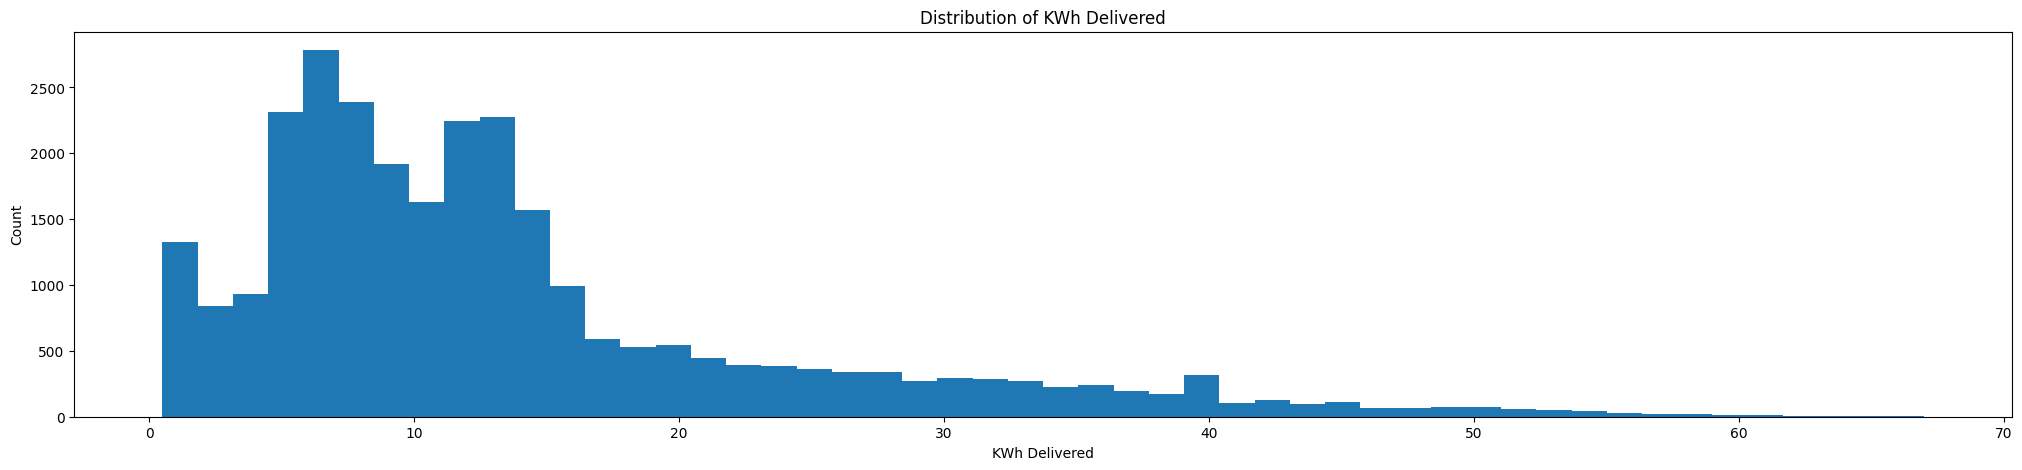

In [ ]:
plt.figure(figsize=(25, 5))
plt.hist(jpl_dataframe['kWhDelivered'], bins=50)
plt.xlabel('KWh Delivered')
plt.ylabel('Count')
plt.title('Distribution of KWh Delivered')
plt.show()

In [ ]:
fig = px.histogram(jpl_dataframe, x='kWhDelivered', nbins=50)
fig.update_layout(
    xaxis_title='KWh Delivered',
    yaxis_title='Count',
    title='Distribution of KWh Delivered'
)
fig.show()

In [ ]:
x = jpl_dataframe['total_charging_time']
percentiles = [8, 9, 10]
for p in percentiles:
    percentile = stats.percentileofscore(x, p)
    print(f"{p} Hour Charging Time is in the {percentile:.2f} percentile")

8 Hour Charging Time is in the 91.28 percentile
9 Hour Charging Time is in the 94.98 percentile
10 Hour Charging Time is in the 98.27 percentile


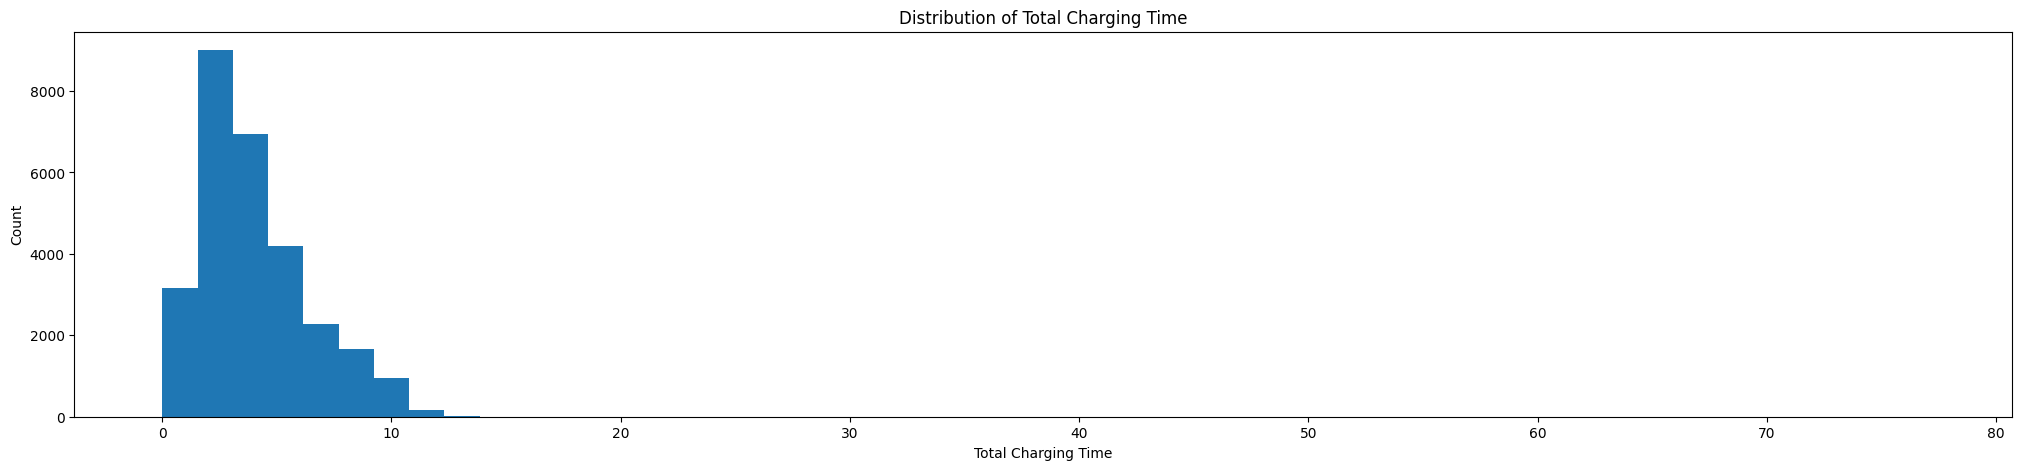

In [ ]:
plt.figure(figsize=(25, 5))
plt.hist(jpl_dataframe['total_charging_time'], bins=50)
plt.xlabel('Total Charging Time')
plt.ylabel('Count')
plt.title('Distribution of Total Charging Time')
plt.show()

In [ ]:
fig = px.histogram(jpl_dataframe, x='total_charging_time', nbins=50)
fig.update_layout(
    xaxis_title='Total Charging Time',
    yaxis_title='Count',
    title='Distribution of Total Charging Time'
)
fig.show()

In [ ]:
x = jpl_dataframe['idle_time']
percentiles = [10, 11, 12, 13, 24]
for p in percentiles:
    percentile = stats.percentileofscore(x, p)
    print(f"{p} Hour Idle Time is in the {percentile:.2f} percentile")

10 Hour Idle Time is in the 99.34 percentile
11 Hour Idle Time is in the 99.63 percentile
12 Hour Idle Time is in the 99.74 percentile
13 Hour Idle Time is in the 99.80 percentile
24 Hour Idle Time is in the 99.97 percentile


In [ ]:
fig = px.histogram(jpl_dataframe, x='idle_time', nbins=50)
fig.update_layout(
    xaxis_title='Total Idle Time',
    yaxis_title='Count',
    title='Distribution of Total Idle Time'
)
fig.show()

In [ ]:
jpl_dataframe_before_COVID = jpl_dataframe.loc[jpl_dataframe['connectionTime'] < pd.to_datetime('2020-03-15')]
jpl_dataframe_before_COVID.shape

(21052, 6)

**Removing Some outliers where kWhDelivered > 40, total_charging_time > 10 and idle_time > 12**

In [ ]:
jpl_dataframe_before_COVID = jpl_dataframe_before_COVID[jpl_dataframe_before_COVID['kWhDelivered'] <= 40].reset_index(drop=True)
jpl_dataframe_before_COVID = jpl_dataframe_before_COVID[jpl_dataframe_before_COVID['total_charging_time'] <= 10].reset_index(drop=True)
jpl_dataframe_before_COVID = jpl_dataframe_before_COVID[jpl_dataframe_before_COVID['idle_time'] <= 12].reset_index(drop=True)
jpl_dataframe_before_COVID

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
0,2018-10-08 07:01:14,11.694,1,179781,9.980278,0.313611
1,2018-10-08 07:06:38,7.534,1,179791,9.890278,0.216667
2,2018-10-08 07:07:27,20.679,1,179799,9.876667,0.365833
3,2018-10-08 07:20:19,8.418,1,179794,9.661667,0.843611
4,2018-10-08 07:27:14,17.105,1,191803,9.982778,0.604444
...,...,...,...,...,...,...
19799,2020-03-13 12:36:58,0.819,1,179781,2.902778,2.165278
19800,2020-03-13 12:45:58,9.355,1,178824,1.613333,0.001111
19801,2020-03-13 14:44:08,14.263,1,179815,2.267778,0.304444
19802,2020-03-14 09:43:29,21.546,1,193829,3.423611,0.555278


# Addressing duplicacy in `connectionTime`

**Checking how many duplicates are there for the same `connectionTime`**

In [ ]:
# Find the duplicated rows based on the 'connectionTime' column
duplicated_df = jpl_dataframe_before_COVID[jpl_dataframe_before_COVID.duplicated(subset=['connectionTime'], keep=False)]

duplicated_df

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
179,2018-10-11 07:14:41,22.451,1,179783,4.133056,7.383611
180,2018-10-11 07:14:41,11.060,1,179800,2.982778,6.568056
1711,2018-11-15 06:58:44,5.205,1,179809,0.890833,6.149722
1712,2018-11-15 06:58:44,11.913,1,179800,3.970000,4.684167
2809,2018-12-13 08:25:18,6.832,1,191786,5.169722,0.001111
...,...,...,...,...,...,...
17722,2020-01-16 07:31:03,24.670,1,179797,6.179444,3.346111
18592,2020-02-11 07:06:49,11.741,1,179777,3.948611,5.342500
18593,2020-02-11 07:06:49,10.900,1,179815,4.487222,5.479444
18656,2020-02-12 07:15:51,12.211,1,191792,4.031111,5.061111


**154 duplicates. We need to handle them**

In [ ]:
len(duplicated_df)

154

In [ ]:
jpl_dataframe_before_COVID.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19804 entries, 0 to 19803
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       19804 non-null  datetime64[ns]
 1   kWhDelivered         19804 non-null  float64       
 2   siteID               19804 non-null  int64         
 3   stationID            19804 non-null  int64         
 4   total_charging_time  19804 non-null  float64       
 5   idle_time            19804 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 928.4 KB


**The unique hours that we have duplicacy**

In [ ]:
unique_hours = duplicated_df['connectionTime'].dt.hour.unique()
unique_hours

array([ 7,  6,  8,  5, 12, 14])

**At the given duplicate hours we are finding out the maximum occuring `stationID`for the whole time period.**

In [ ]:
df = jpl_dataframe_before_COVID.copy()
df['connectionTime'] = pd.to_datetime(df['connectionTime'])

df['hour'] = df['connectionTime'].dt.hour

df_filtered = df[df['hour'].isin(unique_hours)]


grouped = df_filtered.groupby(['hour', 'stationID']).size()


for hour in unique_hours:
    max_station = grouped[hour].idxmax()
    print(f"At hour {hour}, stationID {max_station} had the highest count.")

At hour 7, stationID 191782 had the highest count.
At hour 6, stationID 193820 had the highest count.
At hour 8, stationID 191786 had the highest count.
At hour 5, stationID 178823 had the highest count.
At hour 12, stationID 194821 had the highest count.
At hour 14, stationID 194821 had the highest count.


**Also sorting the occurance of `stationID` from highest to lowest for a particular hour (obviously duplicated unique hours)**

In [ ]:
unique_hours = duplicated_df['connectionTime'].dt.hour.unique()

df = jpl_dataframe_before_COVID.copy()
df['connectionTime'] = pd.to_datetime(df['connectionTime'])
df['hour'] = df['connectionTime'].dt.hour
df_filtered = df[df['hour'].isin(unique_hours)]

grouped = df_filtered.groupby(['hour', 'stationID']).size().reset_index(name='count')

for hour in unique_hours:
    hour_df = grouped[grouped['hour'] == hour].sort_values('count', ascending=False)
    print(f"At hour {hour}, the occurrences of stationID from highest to lowest are:")
    for index, row in hour_df.iterrows():
        print(f"{row['stationID']}: {row['count']} occurrences")

At hour 7, the occurrences of stationID from highest to lowest are:
191782: 246 occurrences
191807: 235 occurrences
191805: 235 occurrences
191792: 233 occurrences
191812: 231 occurrences
191778: 226 occurrences
191780: 224 occurrences
191806: 217 occurrences
191795: 217 occurrences
179779: 215 occurrences
191811: 213 occurrences
179790: 199 occurrences
191793: 189 occurrences
179798: 189 occurrences
191803: 187 occurrences
191786: 187 occurrences
191784: 187 occurrences
179813: 183 occurrences
179801: 183 occurrences
191808: 182 occurrences
191802: 165 occurrences
191785: 160 occurrences
179794: 154 occurrences
179809: 150 occurrences
179777: 141 occurrences
191804: 136 occurrences
179783: 131 occurrences
179788: 123 occurrences
179791: 118 occurrences
179787: 112 occurrences
179781: 112 occurrences
179797: 95 occurrences
179815: 93 occurrences
179796: 77 occurrences
179800: 73 occurrences
179810: 61 occurrences
191789: 47 occurrences
194818: 43 occurrences
193816: 35 occurrences
1948

**The duplicates for stationID at the same time are handled by selecting the stationID with the highest count for each hour (if available). If no such stationID is found, random rows are selected to ensure a minimum number of samples (n_samples) for that hour.**

In [ ]:
n_samples = 1

duplicated_df = duplicated_df.assign(hour=duplicated_df['connectionTime'].dt.hour)


df_filtered = duplicated_df[duplicated_df['hour'].isin(unique_hours)]


for hour in unique_hours:
    df_hour = df_filtered[df_filtered['hour'] == hour]

    grouped = df_hour.groupby('stationID').size().reset_index(name='count')

    grouped.sort_values('count', ascending=False, inplace=True)

    selected_stationID = None
    for stationID in grouped['stationID']:
        if not df_filtered[(df_filtered['hour'] == hour) & (df_filtered['stationID'] == stationID)].empty:
            selected_stationID = stationID
            break

    if selected_stationID is None:
        df_selected = df_filtered[df_filtered['hour'] == hour].sample(n=min(n_samples, len(df_filtered[df_filtered['hour'] == hour])), random_state=SEED)
    else:
        df_selected = df_filtered[(df_filtered['hour'] != hour) | (df_filtered['stationID'] == selected_stationID)]
    if hour == unique_hours[0]:
        df_final = df_selected
    else:
        df_final = pd.concat([df_final, df_selected])

df_final.drop_duplicates(subset='connectionTime', inplace=True)
selected_rows = df_final[df_final['connectionTime'] == '2018-10-11 07:14:41']
selected_rows

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time,hour
179,2018-10-11 07:14:41,22.451,1,179783,4.133056,7.383611,7


In [ ]:
df_final.shape

(62, 7)

In [ ]:
jpl_dataframe_before_COVID.shape

(19804, 6)

In [ ]:
selected_rows = jpl_dataframe_before_COVID[jpl_dataframe_before_COVID['connectionTime'] == '2018-10-11 07:14:41']
selected_rows

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
179,2018-10-11 07:14:41,22.451,1,179783,4.133056,7.383611
180,2018-10-11 07:14:41,11.060,1,179800,2.982778,6.568056


In [ ]:
# Drop all the duplicate rows based on the 'connectionTime' column from the original dataframe
jpl_dataframe_before_COVID.drop_duplicates(subset=['connectionTime'], keep=False, inplace=True)

In [ ]:
jpl_dataframe_before_COVID.shape

(19650, 6)

In [ ]:
selected_rows = jpl_dataframe_before_COVID[jpl_dataframe_before_COVID['connectionTime'] == '2018-10-11 07:14:41']
selected_rows

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time


In [ ]:
duplicates = jpl_dataframe_before_COVID.duplicated(subset='connectionTime')
if duplicates.any():
    print('There are duplicates based on the connectionTime column.')
else:
    print('There are no duplicates based on the connectionTime column.')

There are no duplicates based on the connectionTime column.


In [ ]:
# Concatenate the selected_rows DataFrame to jpl_dataframe_before_COVID
jpl_dataframe_before_COVID = pd.concat([jpl_dataframe_before_COVID, df_final], ignore_index=True)
jpl_dataframe_before_COVID.shape

(19712, 7)

In [ ]:
jpl_dataframe_before_COVID

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time,hour
0,2018-10-08 07:01:14,11.694,1,179781,9.980278,0.313611,NaN
1,2018-10-08 07:06:38,7.534,1,179791,9.890278,0.216667,NaN
2,2018-10-08 07:07:27,20.679,1,179799,9.876667,0.365833,NaN
3,2018-10-08 07:20:19,8.418,1,179794,9.661667,0.843611,NaN
4,2018-10-08 07:27:14,17.105,1,191803,9.982778,0.604444,NaN
...,...,...,...,...,...,...,...
19707,2019-10-30 07:15:58,15.146,1,191782,3.498611,7.080000,7.0
19708,2019-11-15 07:23:57,11.043,1,191792,4.989444,5.042222,7.0
19709,2020-01-16 07:31:03,16.857,1,191803,5.688611,0.405000,7.0
19710,2020-02-11 07:06:49,11.741,1,179777,3.948611,5.342500,7.0


In [ ]:
selected_rows = jpl_dataframe_before_COVID[jpl_dataframe_before_COVID['connectionTime'] == '2018-10-11 07:14:41']
selected_rows

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time,hour
19679,2018-10-11 07:14:41,22.451,1,179783,4.133056,7.383611,7.0


In [ ]:
# Drop the 'hour' column from the dataframe
jpl_dataframe_before_COVID.drop('hour', axis=1, inplace=True)

In [ ]:
jpl_dataframe_before_COVID.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19712 entries, 0 to 19711
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       19712 non-null  datetime64[ns]
 1   kWhDelivered         19712 non-null  float64       
 2   siteID               19712 non-null  int64         
 3   stationID            19712 non-null  int64         
 4   total_charging_time  19712 non-null  float64       
 5   idle_time            19712 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 924.1 KB


**Finally done! 😊**

In [ ]:
duplicates = jpl_dataframe_before_COVID.duplicated(subset='connectionTime')
if duplicates.any():
    print('There are duplicates based on the connectionTime column.')
else:
    print('There are no duplicates based on the connectionTime column.')


There are no duplicates based on the connectionTime column.


# Isolation Forest - Anomaly detection

**Checked Isolation Forest. But seems not helpful that much! Still deciding to keep or not**

In [ ]:
features = ['kWhDelivered', 'total_charging_time', 'idle_time']

model = IsolationForest(n_estimators=100, max_samples='auto', contamination=0.1, verbose = False, max_features=3, random_state=SEED)
model.fit(jpl_dataframe_before_COVID[features].values)

IsolationForest(contamination=0.1, max_features=3, random_state=42,
                verbose=False)

In [ ]:
print(model.get_params())

{'bootstrap': False, 'contamination': 0.1, 'max_features': 3, 'max_samples': 'auto', 'n_estimators': 100, 'n_jobs': None, 'random_state': 42, 'verbose': False, 'warm_start': False}


In [ ]:
jpl_dataframe_before_COVID['scores'] = model.decision_function(jpl_dataframe_before_COVID[features].values)
jpl_dataframe_before_COVID['anomaly'] = model.predict(jpl_dataframe_before_COVID[features].values)

In [ ]:
anomaly=jpl_dataframe_before_COVID.loc[jpl_dataframe_before_COVID['anomaly']==-1]
anomaly_index=list(anomaly.index)
anomaly

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time,scores,anomaly
0,2018-10-08 07:01:14,11.694,1,179781,9.980278,0.313611,-0.033324,-1
1,2018-10-08 07:06:38,7.534,1,179791,9.890278,0.216667,-0.044912,-1
2,2018-10-08 07:07:27,20.679,1,179799,9.876667,0.365833,-0.038542,-1
3,2018-10-08 07:20:19,8.418,1,179794,9.661667,0.843611,-0.032559,-1
4,2018-10-08 07:27:14,17.105,1,191803,9.982778,0.604444,-0.036126,-1
...,...,...,...,...,...,...,...,...
19691,2019-06-17 07:34:25,31.716,1,191780,7.755833,2.117500,-0.007026,-1
19695,2019-07-08 07:21:46,0.963,1,191808,7.193889,1.603889,-0.027927,-1
19698,2019-07-08 07:46:17,8.318,1,179797,9.717778,0.280833,-0.026879,-1
19700,2019-07-16 07:19:49,15.431,1,191786,9.566111,0.181667,-0.012781,-1


In [ ]:
# Drop the rows with anomalies
jpl_dataframe_before_COVID = jpl_dataframe_before_COVID.loc[jpl_dataframe_before_COVID['anomaly'] != -1].copy()
# Drop the "anomaly" and "score" columns
jpl_dataframe_before_COVID.drop(columns=["anomaly", "scores"], inplace=True)

# Some visualization

**Some visualization. But not important!**

In [ ]:
# First, make sure the connectionTime column is a datetime type
df['connectionTime'] = pd.to_datetime(df['connectionTime'])

# Extract the hour from the connectionTime column
df['hour'] = df['connectionTime'].dt.hour

# Then, filter the DataFrame to only include rows with the hours of interest
hours_of_interest = list(range(0, 24))
df_filtered = df[df['hour'].isin(hours_of_interest)]

# Group the filtered DataFrame by hour and stationID, and count the occurrences of each
grouped = df_filtered.groupby(['hour', 'stationID']).size().reset_index(name='count')

# Get the stationID with the highest count for each hour of interest
for hour in hours_of_interest:
    df_hour = grouped[grouped['hour'] == hour]
    max_station = df_hour.loc[df_hour['count'].idxmax(), 'stationID']
    max_count = df_hour['count'].max()
    print(f"At hour {hour}, stationID {max_station} had the highest count with {max_count} occurrences.")


At hour 0, stationID 178823 had the highest count with 6 occurrences.
At hour 1, stationID 178823 had the highest count with 1 occurrences.
At hour 2, stationID 193819 had the highest count with 1 occurrences.
At hour 3, stationID 194821 had the highest count with 26 occurrences.
At hour 4, stationID 194826 had the highest count with 61 occurrences.
At hour 5, stationID 178823 had the highest count with 314 occurrences.
At hour 6, stationID 193820 had the highest count with 272 occurrences.
At hour 7, stationID 191782 had the highest count with 246 occurrences.
At hour 8, stationID 191786 had the highest count with 56 occurrences.
At hour 9, stationID 194822 had the highest count with 13 occurrences.
At hour 10, stationID 194821 had the highest count with 20 occurrences.
At hour 11, stationID 193829 had the highest count with 37 occurrences.
At hour 12, stationID 194821 had the highest count with 32 occurrences.
At hour 13, stationID 194821 had the highest count with 51 occurrences.
At

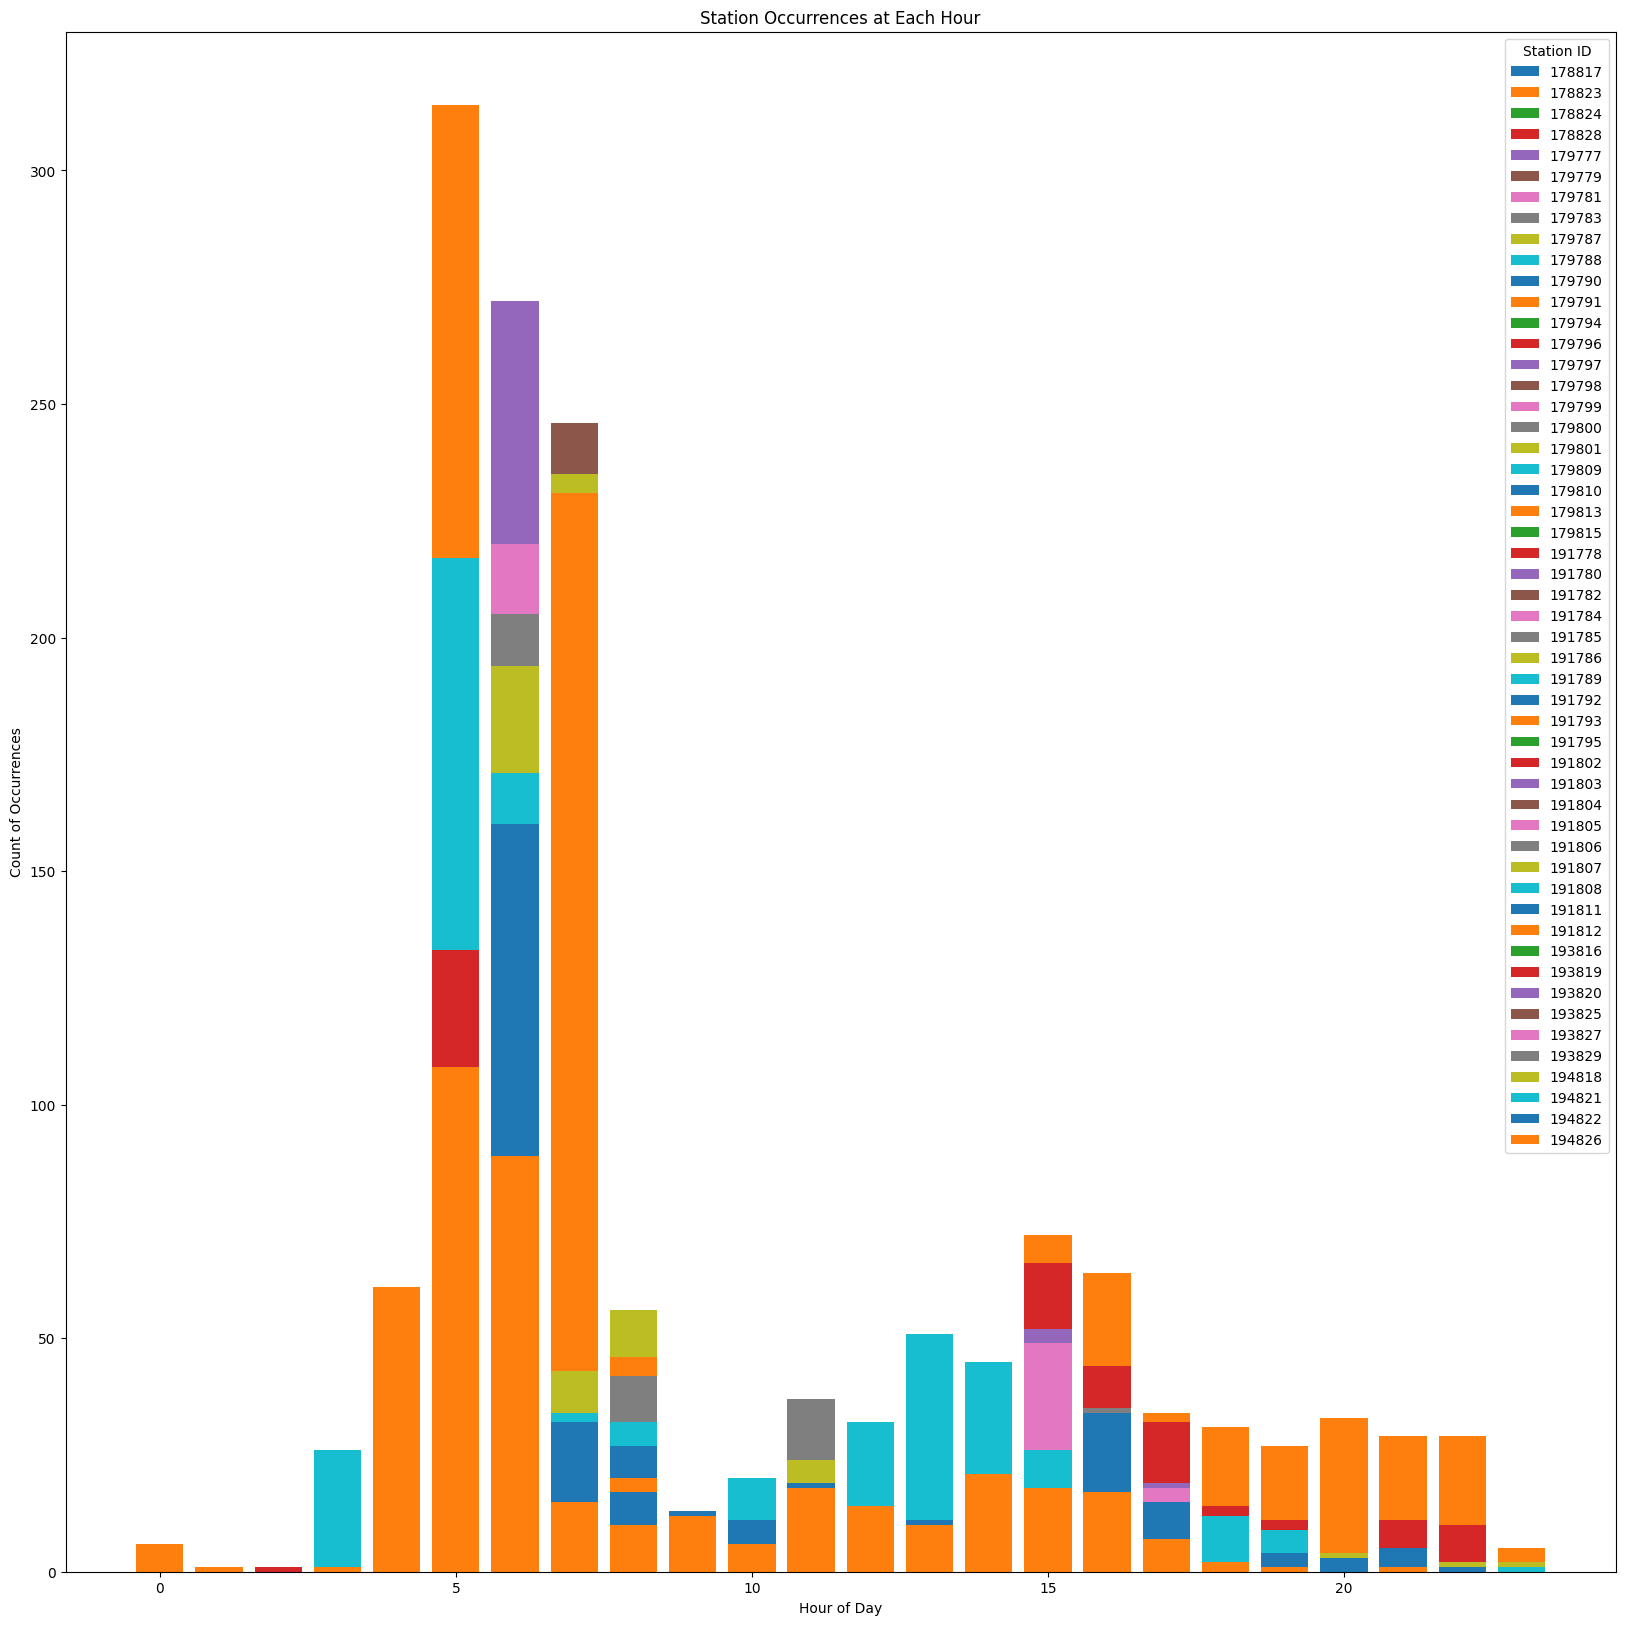

In [ ]:
import matplotlib.pyplot as plt

# Group the filtered DataFrame by hour and stationID, and count the occurrences of each
grouped = df_filtered.groupby(['hour', 'stationID']).size().reset_index(name='count')

# Plot a histogram of the station occurrences at each hour
fig, ax = plt.subplots(figsize=(20, 20))
for name, group in grouped.groupby('stationID'):
    ax.bar(group['hour'], group['count'], label=name)

# Add labels and legend
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Count of Occurrences')
ax.set_title('Station Occurrences at Each Hour')
ax.legend(title='Station ID')
plt.show()

# Save the preprocessed Dataframe

In [ ]:
file_path = '../../../data/preprocessed/ACN/acn_jpl_0.2_0.1_with_stationID_22_06_2023.csv'
jpl_dataframe_before_COVID.to_csv(file_path, index=False)